In [1]:
# 1. Import Libraries
import warnings
warnings.filterwarnings("ignore")

import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.load_data import load_data
from src.data.preprocess import preprocess_data

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# 2. Load Dataset
df = load_data(path="../data/raw/heart.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
# 3. Dataset Overview
print("Dataset Shape:")
print(df.shape)
df.head()
df.info()
df.describe().T

Dataset Shape:
(297, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       297 non-null    float64
 1   sex       297 non-null    float64
 2   cp        297 non-null    float64
 3   trestbps  297 non-null    float64
 4   chol      297 non-null    float64
 5   fbs       297 non-null    float64
 6   restecg   297 non-null    float64
 7   thalach   297 non-null    float64
 8   exang     297 non-null    float64
 9   oldpeak   297 non-null    float64
 10  slope     297 non-null    float64
 11  ca        297 non-null    float64
 12  thal      297 non-null    float64
 13  target    297 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 32.6 KB


,count,mean,std,min,25%,50%,75%,max
age,297.0,54.542088,9.049736,29.0,48.0,56.0,61.0,77.0
sex,297.0,0.676768,0.468500,0.0,0.0,1.0,1.0,1.0
cp,297.0,3.158249,0.964859,1.0,3.0,3.0,4.0,4.0
trestbps,297.0,131.693603,17.762806,94.0,120.0,130.0,140.0,200.0
chol,297.0,247.350168,51.997583,126.0,211.0,243.0,276.0,564.0
fbs,297.0,0.144781,0.352474,0.0,0.0,0.0,0.0,1.0
restecg,297.0,0.996633,0.994914,0.0,0.0,1.0,2.0,2.0
thalach,297.0,149.599327,22.941562,71.0,133.0,153.0,166.0,202.0
exang,297.0,0.326599,0.469761,0.0,0.0,0.0,1.0,1.0
oldpeak,297.0,1.055556,1.166123,0.0,0.0,0.8,1.6,6.2


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


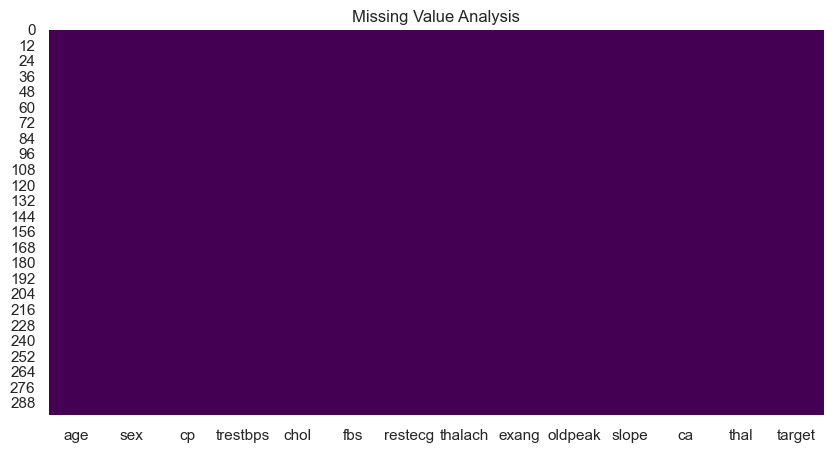

In [4]:
# 4. Missing Value Analysis
print(df.isnull().sum())
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Analysis")
plt.show()

In [5]:
#5. Data Preprocessing
df = preprocess_data(df)

print(df.head())

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0     0.0  
1    2.0  3.0   3.0     1.0  
2    2.0  2.0   7.0     1.0  
3    3.0  0.0   3.0     0.0  
4    1.0  0.0   3.0     0.0  


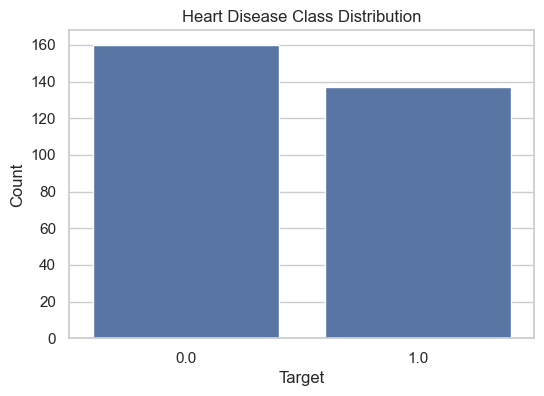

target
0.0    160
1.0    137
Name: count, dtype: int64
target
0.0    0.538721
1.0    0.461279
Name: proportion, dtype: float64


In [6]:
# 6. Class Balance
plt.figure(figsize=(6,4))

sns.countplot(
    x="target",
    data=df
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

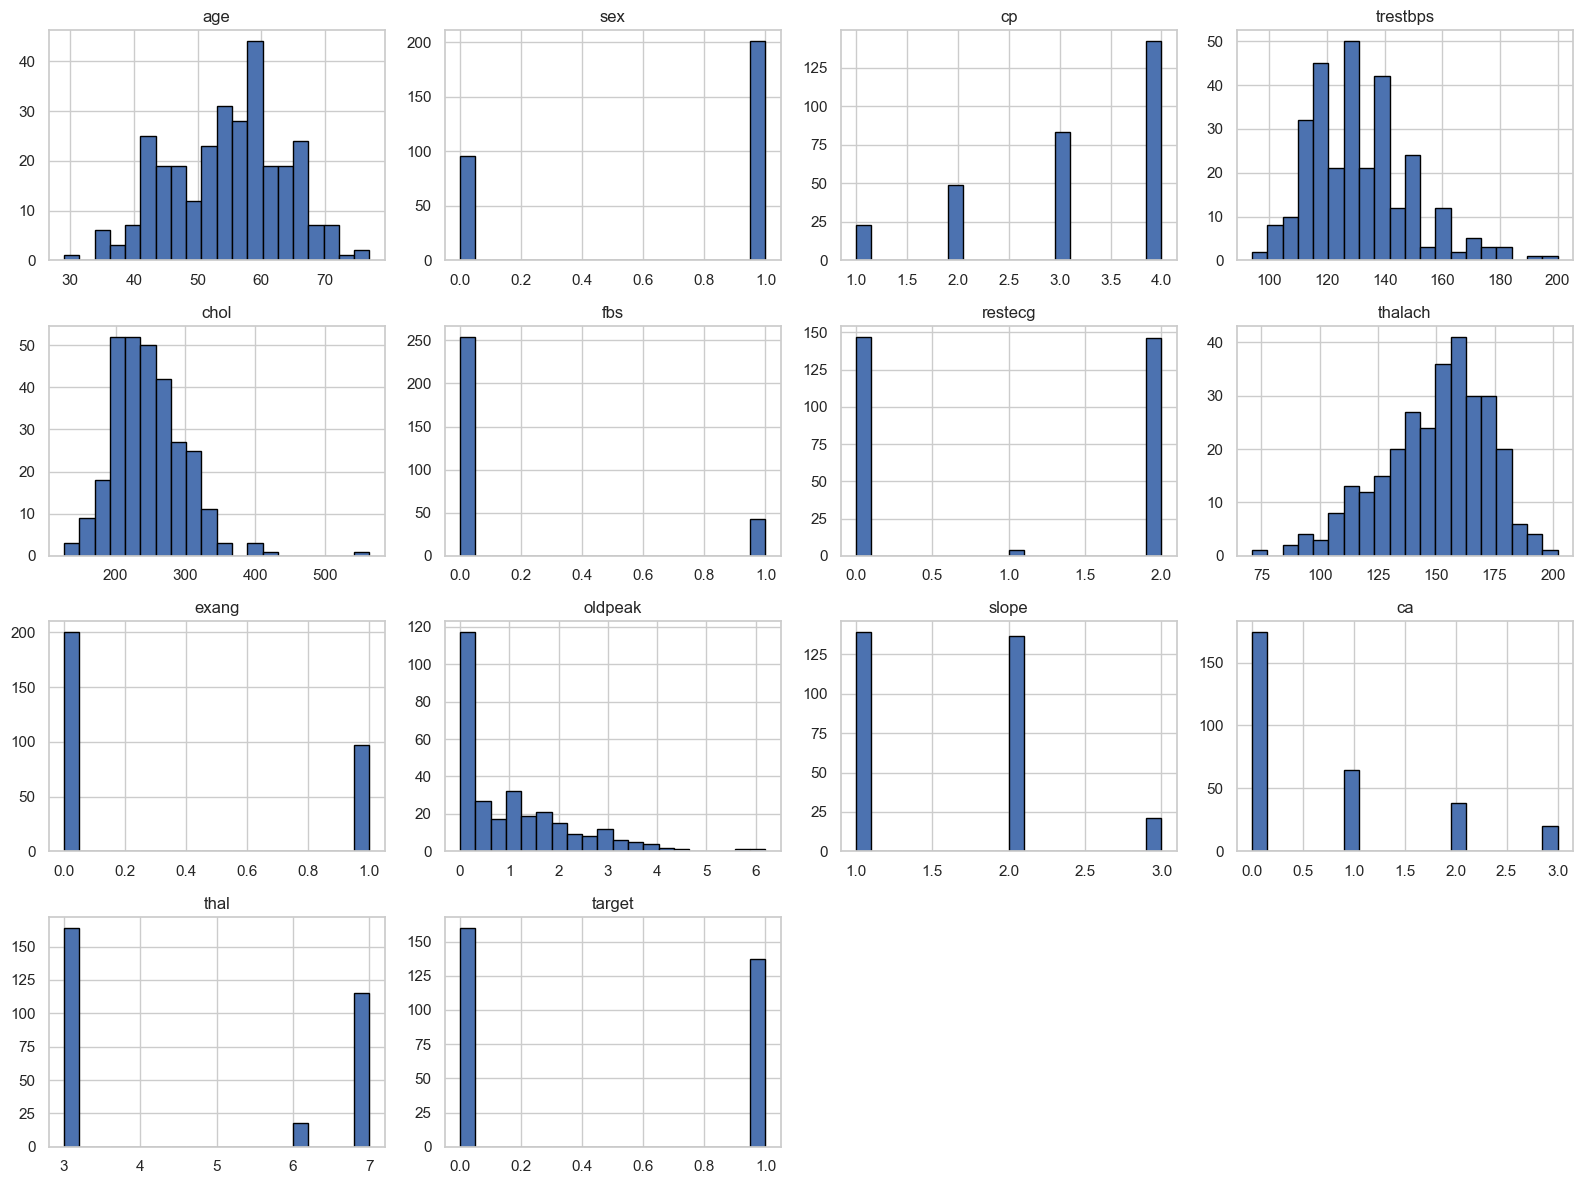

In [7]:
# 7. Histograms
df.hist(
    figsize=(16,12),
    bins=20,
    edgecolor="black"
)

plt.tight_layout()
plt.show()

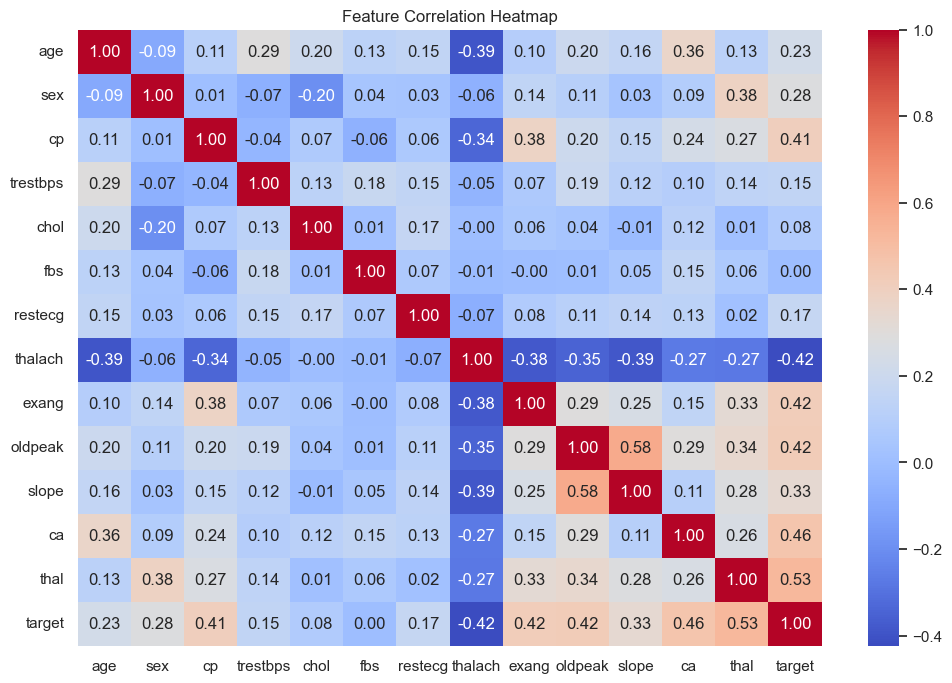

In [8]:
# 8. Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

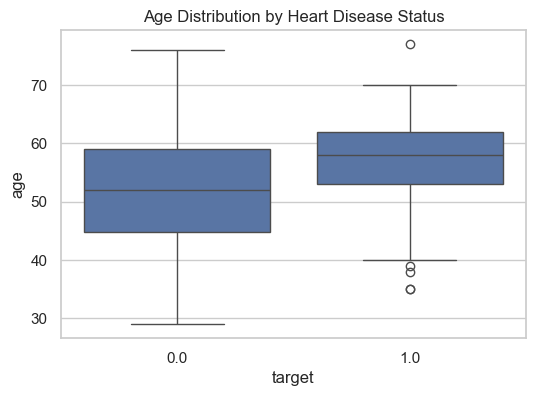

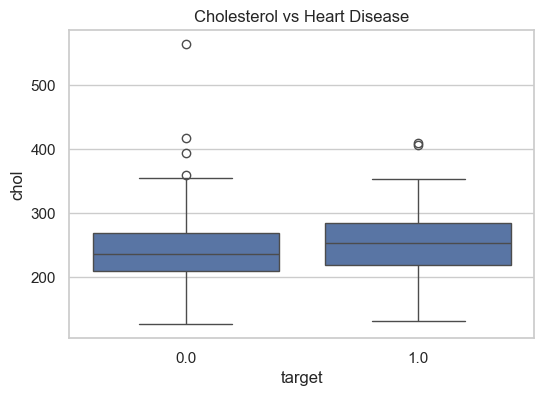

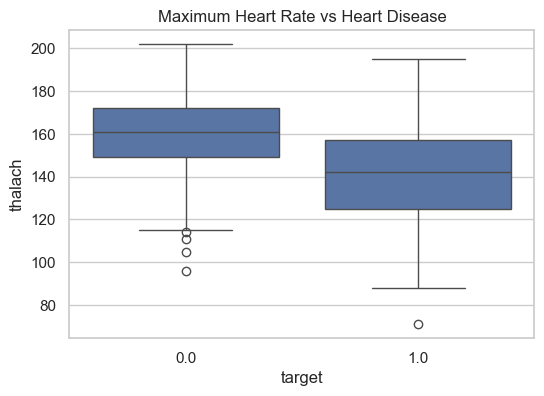

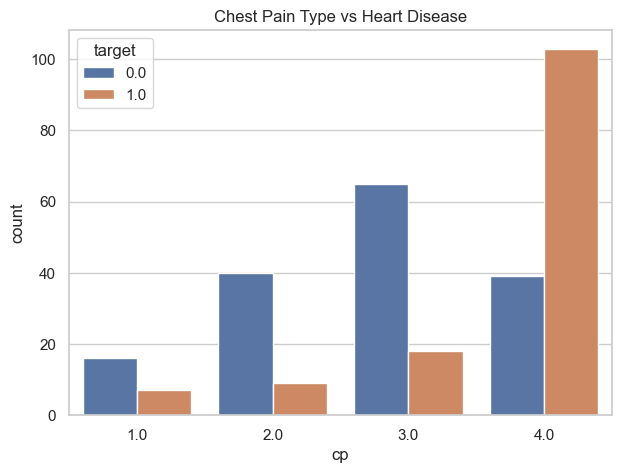

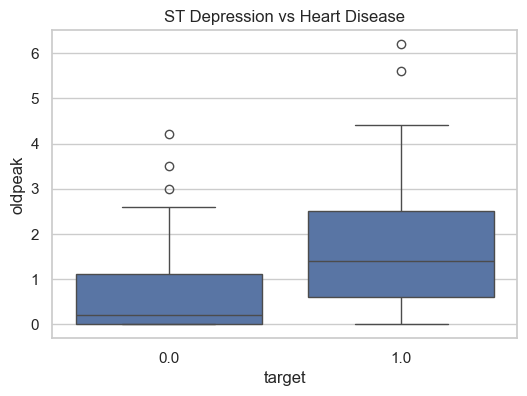

In [9]:
#9. Target Relationship Analysis
# Age vs Heart Disease
plt.figure(figsize=(6,4))

sns.boxplot(
    x="target",
    y="age",
    data=df
)

plt.title("Age Distribution by Heart Disease Status")

plt.show()

# Cholesterol vs Heart Disease
plt.figure(figsize=(6,4))

sns.boxplot(
    x="target",
    y="chol",
    data=df
)

plt.title("Cholesterol vs Heart Disease")

plt.show()

# Maximum Heart Rate vs Heart Disease
plt.figure(figsize=(6,4))

sns.boxplot(
    x="target",
    y="thalach",
    data=df
)

plt.title("Maximum Heart Rate vs Heart Disease")

plt.show()

# Chest Pain Type vs Heart Disease
plt.figure(figsize=(7,5))

sns.countplot(
    x="cp",
    hue="target",
    data=df
)

plt.title("Chest Pain Type vs Heart Disease")

plt.show()

#  ST Depression (Oldpeak) vs Heart Disease
plt.figure(figsize=(6,4))

sns.boxplot(
    x="target",
    y="oldpeak",
    data=df
)

plt.title("ST Depression vs Heart Disease")

plt.show()

In [10]:
# 10. Save Processed Dataset
df.to_csv(
    "../data/processed/processed_heart.csv",
    index=False
)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


# Exploratory Data Analysis Summary

### Key Findings

- The dataset contains patient demographic and clinical information used to predict heart disease.
- Missing values were identified and handled using median imputation during preprocessing.
- Duplicate records were removed to improve data quality.
- The target variable is reasonably balanced, making it suitable for classification.
- Features such as **Age**, **Chest Pain Type (cp)**, **Maximum Heart Rate (thalach)**, and **ST Depression (oldpeak)** show stronger relationships with heart disease.
- The correlation heatmap indicates moderate relationships among a few clinical variables, with no evidence of severe multicollinearity.
- The cleaned dataset has been saved and is ready for feature engineering and model development.